#Import Data

In [1]:
import zipfile

In [2]:
#import image data from google drive
!gdown --id '1qCHfycy91EyUFzilBvxu8hYVYp0l6jCh' --output Midterm_dataset.zip

/usr/local/lib/python3.9/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1qCHfycy91EyUFzilBvxu8hYVYp0l6jCh
To: /content/Midterm_dataset.zip
100% 50.4M/50.4M [00:01<00:00, 43.3MB/s]


In [3]:
#解壓縮zip檔到temp
local_zip = 'Midterm_dataset.zip'
zip_ref = zipfile.ZipFile(local_zip,'r')
zip_ref.extractall('temp')
zip_ref.close()

In [4]:
#到MidTerm_Dataset資料夾中
%cd /
%cd content/temp/MidTerm_Dataset

/
/content/temp/MidTerm_Dataset


# Import Library

In [5]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import numpy as np
import os
import pandas as pd 
from sklearn.metrics import confusion_matrix
#import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle           
import matplotlib.pyplot as plt             
import cv2                                 
import tensorflow as tf                
from tqdm import tqdm
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Embedding
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.optimizers import SGD, Adam
import numpy as np
from keras.datasets import mnist
from keras.utils import np_utils,to_categorical
from keras.models import Sequential
from keras.optimizers import Adam
import numpy as np 
import pandas as pd 
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Activation, Conv2D, MaxPooling2D,BatchNormalization,GlobalAveragePooling2D
from tqdm import tqdm
from sklearn.utils import shuffle
from tensorflow.keras.utils import load_img,img_to_array
import random
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load Data to program

In [6]:
class_names = ['bolt','locatingpin','nut','washer']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}
nb_classes = len(class_names)

IMAGE_SIZE = (224, 224)

def load_data():
    datasets = ['Train', 'Test']#資料夾
    output = []
    
    # Iterate through training and test sets
    for dataset in datasets:
        
        images = []
        labels = []
        
        print("Loading {}".format(dataset))
        
        # Iterate through each folder corresponding to a category
        for folder in os.listdir(dataset):
            label = class_names_label[folder]
            
            # Iterate through each image in our folder
            for file in tqdm(os.listdir(os.path.join(dataset, folder))):
                
                # Get the path name of the image
                img_path = os.path.join(os.path.join(dataset, folder), file)
                
                # Open and resize the img
                image = cv2.imread(img_path)
                #print(file,image)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                #cv讀照片，顏色莫認為BGR，需轉為RGB，錯誤表示黑白或已轉
                image = cv2.resize(image, IMAGE_SIZE)
                
                # Append the image and its corresponding label to the output
                images.append(image)
                labels.append(label)
                
        images = np.array(images, dtype = 'float32')
        labels = np.array(labels, dtype = 'int32')   
        output.append((images, labels))
    return output


(x_train,y_train),(x_test,y_test) = load_data()
x_train = x_train.reshape(x_train.shape[0],224,224,1).astype('float32')
x_test = x_test.reshape(x_test.shape[0],224,224,1).astype('float32')

print("x_train shape: ",x_train.shape)
print("x_test shape: ",x_test.shape)

x_train = x_train/255
x_test = x_test/255

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Loading Train


100%|██████████| 1523/1523 [00:01<00:00, 1319.78it/s]


Loading Test


100%|██████████| 381/381 [00:00<00:00, 1726.32it/s]


x_train shape:  (6092, 224, 224, 1)
x_test shape:  (1524, 224, 224, 1)


# Model Building

In [7]:
from tensorflow.keras import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers.experimental import preprocessing

In [8]:
def VGG16(input_shape=(224, 224, 1), num_classes=4):
    img_input = Input(shape=input_shape)

    #block 1
    x = Conv2D(filters=64, kernel_size=(3, 3),
        activation='relu', padding='same')(img_input)
    x = Conv2D(filters=64, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 2
    x = Conv2D(filters=128, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=128, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 3
    x = Conv2D(filters=256, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=256, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=256, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 4
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 5
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #flatten
    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    x = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=img_input, outputs=x)

In [9]:
#建立模型，此處使用經典VGG16模型
model = VGG16()
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 64)      640       
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 64)      36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 64)     0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 112, 112, 128)     73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 112, 112, 128)     147584    
                                                             

# Compile the model

In [10]:
from tensorflow.keras.optimizers import Adam


model.compile(
    loss='categorical_crossentropy', #多元分類問題(整數標籤)，故使用此損失函數
    metrics=['accuracy'],
    optimizer=Adam(learning_rate=0.0001)  #lr:學習率 = 0.0001
    #optimizer='adam' #用這種方法也行，但只能使用預設參數
    )

# Training

In [11]:
train_history = model.fit(
    x_train,y_train,
    epochs=50,
    verbose=1,
    validation_split=0.2,
    use_multiprocessing=True,
    batch_size=32
    )

Epoch 1/50
153/153 [==============================] - 99s 477ms/step - loss: 1.2798 - accuracy: 0.3183 - val_loss: 2.5961 - val_accuracy: 0.0000e+00
Epoch 2/50
153/153 [==============================] - 68s 447ms/step - loss: 1.1995 - accuracy: 0.3725 - val_loss: 2.3961 - val_accuracy: 0.0000e+00
Epoch 3/50
153/153 [==============================] - 69s 451ms/step - loss: 0.5079 - accuracy: 0.8276 - val_loss: 0.8403 - val_accuracy: 0.4938
Epoch 4/50
153/153 [==============================] - 69s 450ms/step - loss: 0.2845 - accuracy: 0.8955 - val_loss: 0.5139 - val_accuracy: 0.7933
Epoch 5/50
153/153 [==============================] - 68s 447ms/step - loss: 0.1948 - accuracy: 0.9249 - val_loss: 0.6648 - val_accuracy: 0.7416
Epoch 6/50
153/153 [==============================] - 69s 450ms/step - loss: 0.1488 - accuracy: 0.9436 - val_loss: 0.3960 - val_accuracy: 0.8400
Epoch 7/50
153/153 [==============================] - 69s 452ms/step - loss: 0.1033 - accuracy: 0.9602 - val_loss: 0.8003 

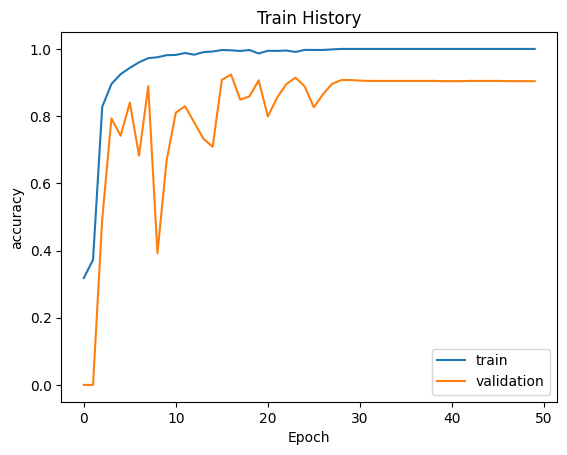

In [12]:
import matplotlib.pyplot as plt

plt.plot(train_history.history['accuracy'])
plt.plot(train_history.history['val_accuracy'])
plt.title('Train History')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.savefig('Train_History_accuracy.png')

plt.show()

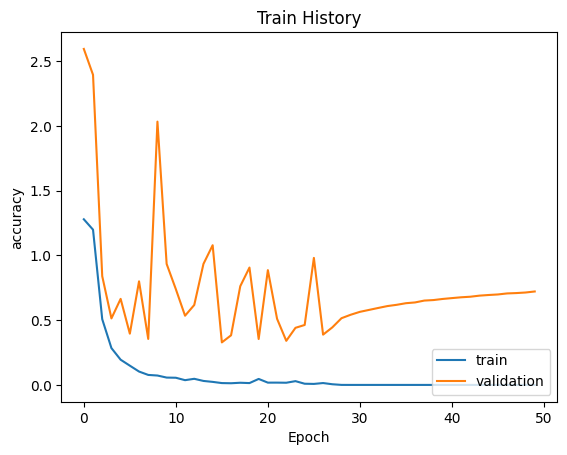

In [15]:
plt.plot(train_history.history['loss'])
plt.plot(train_history.history['val_loss'])
plt.title('Train History')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.savefig('Train_History_accuracy.png')

plt.show()